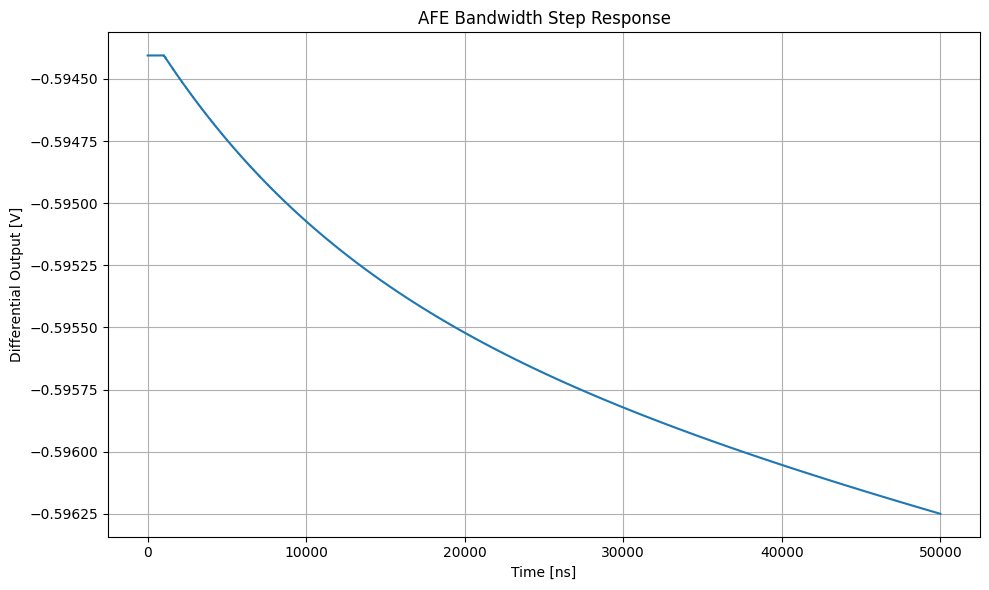


========== BANDWIDTH TRANSIENT REPORT ==========
Rise Time (10-90%):        37489.00 ns
Estimated -3 dB BW:        0.01 MHz



In [4]:
from PyLTSpice import RawRead
import matplotlib.pyplot as plt
import numpy as np
import os

# ============================================================
# Configuration
# ============================================================
raw_path = "/workspace/Hardware/DesignVerification/CircuitModels/AFE/TbBandwidthStep.raw"
report_root = "./Reports"
os.makedirs(report_root, exist_ok=True)

# ============================================================
# Load RAW File
# ============================================================
raw = RawRead(raw_path)

time = np.real(raw.get_trace("time").get_wave(0))
vout_p = raw.get_trace("V(out_p)").get_wave(0)
vout_n = raw.get_trace("V(out_n)").get_wave(0)

vdiff = np.real(vout_p - vout_n)

# ------------------------------------------------------------
# Rise Time Measurement (10% to 90%) - Polarity Independent
# ------------------------------------------------------------

v_start = vdiff[0]
v_end = np.mean(vdiff[-100:])

delta = v_end - v_start

v_10 = v_start + 0.1 * delta
v_90 = v_start + 0.9 * delta

t_10 = None
t_90 = None

for i in range(len(vdiff)):
    if delta > 0:
        if t_10 is None and vdiff[i] >= v_10:
            t_10 = time[i]
        if t_90 is None and vdiff[i] >= v_90:
            t_90 = time[i]
            break
    else:
        if t_10 is None and vdiff[i] <= v_10:
            t_10 = time[i]
        if t_90 is None and vdiff[i] <= v_90:
            t_90 = time[i]
            break

if t_10 is not None and t_90 is not None and (t_90 > t_10):
    rise_time = t_90 - t_10
    bandwidth_est = 0.35 / rise_time
else:
    rise_time = None
    bandwidth_est = None

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(time * 1e9, vdiff)
plt.xlabel("Time [ns]")
plt.ylabel("Differential Output [V]")
plt.title("AFE Bandwidth Step Response")
plt.grid(True)
plt.tight_layout()

plt.savefig(os.path.join(report_root, "AFEBandwidthStepResponse.svg"),
            format="svg")
plt.show()

# ============================================================
# Summary
# ============================================================

print("\n========== BANDWIDTH TRANSIENT REPORT ==========")

if rise_time is not None:
    print(f"Rise Time (10-90%):        {rise_time*1e9:.2f} ns")
    print(f"Estimated -3 dB BW:        {bandwidth_est/1e6:.2f} MHz")
else:
    print("Rise Time:                 Could not determine")

print("================================================\n")